In [14]:
import time
import h5py
from scipy import stats as st
import numpy as np
import matplotlib.pyplot as plt
import sys

from chemrixs.average import Average
from chemrixs.smalldata import SmallData
from chemrixs.process import Reduced
from chemrixs.utils import *
from pathlib import Path
%matplotlib widget 

In [15]:
import h5py
import numpy as np
import yaml
import matplotlib.pyplot as plt

# --- config ---
base = '/sdf/data/lcls/ds/rix/'
exp  = 'rix101231825'
run  = 140
fyaml_path = '../roi_input.yml'         # swap to ferufe/roi_input_ferufe.yml if needed
n_show     = -1                       # subsample for speed
# fname = f'{base}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
fname = f'{base}/{exp}/hdf5/smalldata/run140_th100_tha480/{exp}_Run{run:04d}.h5' 

fname_dr   = f'{base}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'          # original
fname_raw  = f'{base}/{exp}/hdf5/smalldata/run140_th100_tha480/{exp}_Run{run:04d}.h5'           # no droplet

with h5py.File(fname_dr, 'r') as h5:
    proj_dr = h5['intg/axis_svls/droplet_dense_curve_corr_pj_ax_1_data'][:]
with h5py.File(fname_raw, 'r') as h5:
    proj_nd = h5['intg/axis_svls/curve_corr_pj_ax_1_data'][:]          # adjust key from h5ls

svls_sum_dr = proj_dr.sum(axis=1)
svls_sum_nd = proj_nd.sum(axis=1)




with open(fyaml_path) as f:
    cfg = yaml.safe_load(f)
fim0_cfg = cfg['fim0']; fim1_cfg = cfg['fim1']

print(fname)


with h5py.File(fname, 'r') as h5:
    print(h5['Sums'].keys())
    print(h5['intg'].keys())
    fim0_wf = h5['intg']['axis_svls']['det_rix_fim0_sum_full_area'][:n_show]   # (shots, channels, samples)
    fim1_wf = h5['intg']['axis_svls']['det_rix_fim1_sum_full_area'][:n_show]
    print(f'fim0 shape: {fim0_wf.shape}, fim1 shape: {fim1_wf.shape}')


with h5py.File(fname_dr, 'r') as h5:
    g       = h5['intg/axis_svls']
    count   = g['count'][:].squeeze()
    monoenc = g['mono_hrencoder_sum_value'][:].squeeze()
    fim0_wf = g['det_rix_fim0_sum_full_area'][:]
    fim1_wf = g['det_rix_fim1_sum_full_area'][:]
    try:
        ek, ea = cfg['epics']['key'], cfg['epics']['attr']['MONO_premirror_pitch']
        premirror = get_premirror_pitch(h5[f'/{ek}/{ea}'][:, 1])
    except Exception:
        premirror = 144506

# ---- count mask: keep frames with the expected number of shots ----
mode_c = st.mode(count, keepdims=False)[0]
cmask  = (count > mode_c-1) & (count < mode_c+1)

# ---- I0 from FIM0 + FIM1, channels 1-4, sig [65:75], bg [0:60] ----
def i0_sum(wf, sig=slice(65, 75), bg=slice(0, 60), channels=(0, 1, 2, 3)):
    ch  = list(channels)
    base = wf[:, ch, bg].mean(axis=-1, keepdims=True)
    return np.abs(wf[:, ch, sig] - base).sum(axis=(-2, -1))

I0_i = i0_sum(fim0_wf) + i0_sum(fim1_wf)

# ---- per-shot mono energy ----
mc = next((np.asarray(r)[2:4] for r in cfg['mono_calib'] if run > r[0] and run < r[1]), None)
assert mc is not None, f'no mono_calib row matches run {run}'
energy_eV = mono_energy(np.polyval(mc, monoenc/count), premirror, fname='../mono_calib.yml')

print(f'{len(count)} shots, mode count = {mode_c}, '
      f'kept by cmask: {cmask.sum()} ({100*cmask.mean():.1f}%)')
print(f'I0: median = {np.median(I0_i):.2e}, range = [{I0_i.min():.2e}, {I0_i.max():.2e}]')
print(f'energy: range = [{np.nanmin(energy_eV):.2f}, {np.nanmax(energy_eV):.2f}] eV')


# # --- plot: mean ± std per channel, with bg_roi (gray) + signal ROI (red) overlaid ---
# fig, axes = plt.subplots(2, 4, figsize=(12, 6), sharex=True)
# nsamp = fim0_wf.shape[-1]; x = np.arange(nsamp)
# rng = np.random.default_rng(0)

# for det_name, wf, det_cfg, axrow in [('fim0', fim0_wf, fim0_cfg, axes[0]),
#                                       ('fim1', fim1_wf, fim1_cfg, axes[1])]:
#     channels, roi, bg_roi = det_cfg['channels'], det_cfg['roi'], det_cfg['bg_roi']
#     for i, c in enumerate(channels):
#         ax = axrow[i]; ch = c - 1   # yaml is 1-indexed
#         m  = wf[:, ch, :].mean(0); s = wf[:, ch, :].std(0)
#         # individual shots (faint)
#         for j in rng.choice(wf.shape[0], 30, replace=False):
#             ax.plot(x, wf[j, ch, :], color='steelblue', alpha=0.1, lw=0.5)
#         ax.plot(x, m, 'k', lw=1.3, label='mean')
#         # ax.fill_between(x, m-s, m+s, color='k', alpha=0.15, label='±1σ')
#         ax.axvspan(bg_roi[0], bg_roi[1], color='gray', alpha=0.25, label='bg_roi')
#         ax.axvspan(roi[i][0], roi[i][1], color='red',  alpha=0.20, label='signal ROI')
#         ax.set_title(f'{det_name} ch{c} (idx {ch})'); ax.set_xlabel('sample')
#         if i == 0: ax.legend(fontsize=8, loc='best')
# plt.tight_layout(); plt.show()

/sdf/data/lcls/ds/rix//rix101231825/hdf5/smalldata/run140_th100_tha480/rix101231825_Run0140.h5
<KeysViewHDF5 ['c_atmopal_calib', 'c_piranha_calib', 'det_crix_w8_calib', 'det_rix_fim0_calib', 'det_rix_fim1_calib', 'fzp_piranha_calib']>
<KeysViewHDF5 ['axis_svls', 'timestamp']>
fim0 shape: (29152, 8, 256), fim1 shape: (29152, 8, 256)
29153 shots, mode count = 335, kept by cmask: 15695 (53.8%)
I0: median = 6.76e+06, range = [3.00e+05, 1.47e+07]
energy: range = [695.44, 711.64] eV


shots: 29153  (matches across both files)
mean SVLS — dropletted: 1.42e+03, no droplet: 1.13e+06, ratio nd/dr: 795.85

1115 shots in 705.00 ± 0.50 eV window


/lscratch/yzy25/tmp/ipykernel_391719/2439764752.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axx.legend(fontsize=9, loc='upper left')


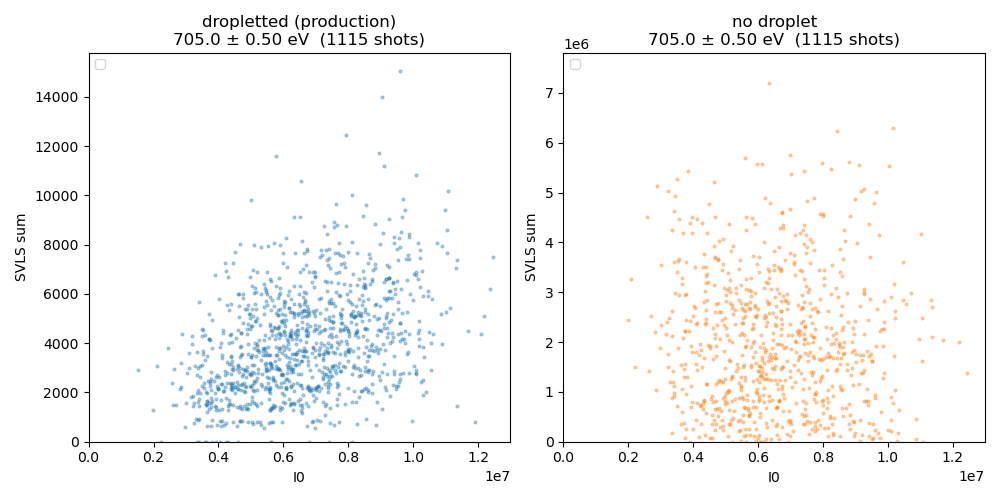

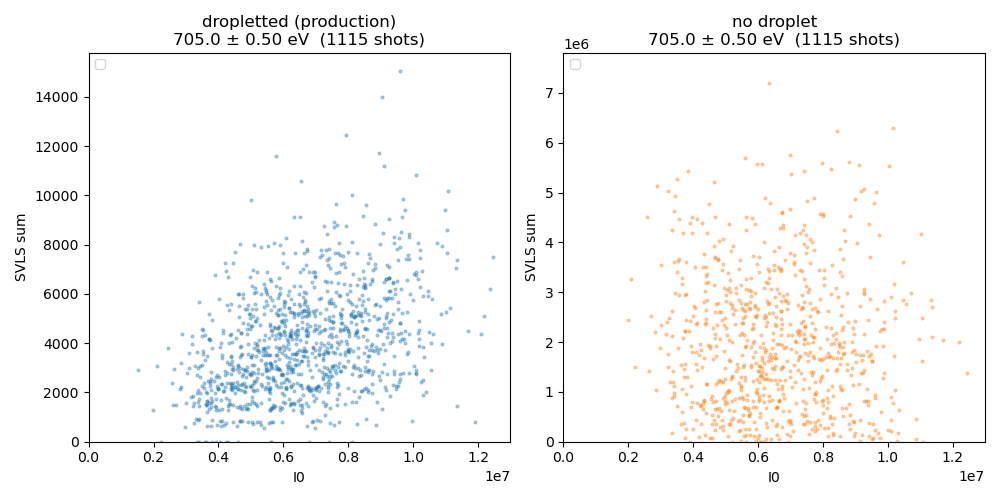

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Assumes you already have in scope from the dropletted SMD:
#   energy_eV, I0_i, cmask   — per-shot, same length as svls_sum_dr / svls_sum_nd
# and from above:
#   svls_sum_dr, svls_sum_nd

# Quick sanity check
assert len(svls_sum_dr) == len(svls_sum_nd) == len(energy_eV), (
    f'shot count mismatch: dr={len(svls_sum_dr)}, nd={len(svls_sum_nd)}, E={len(energy_eV)}'
)
print(f'shots: {len(svls_sum_dr)}  (matches across both files)')
print(f'mean SVLS — dropletted: {svls_sum_dr.mean():.3g}, no droplet: {svls_sum_nd.mean():.3g}, '
      f'ratio nd/dr: {svls_sum_nd.mean()/svls_sum_dr.mean():.2f}')

# ============================================================
#  CHOOSE THE ENERGY TO INSPECT
# ============================================================
E_focus = 705.0
E_width = 1.0
# ============================================================

m = cmask & (energy_eV >= E_focus - E_width/2) & (energy_eV < E_focus + E_width/2)
n_focus = int(m.sum())
print(f'\n{n_focus} shots in {E_focus:.2f} ± {E_width/2:.2f} eV window')

if n_focus < 10:
    print('⚠ too few shots — widen E_width or pick a different E_focus')
else:
    I0 = I0_i[m]
    SV_dr, SV_nd = svls_sum_dr[m], svls_sum_nd[m]

    # ---- side-by-side scatter at the focus energy ----
    fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True)
    for axx, SV, label, dot_color in [
        (ax[0], SV_dr, 'dropletted (production)', 'tab:blue'),
        (ax[1], SV_nd, 'no droplet',              'tab:orange'),
    ]:
        s, b = np.polyfit(I0, SV, 1)
        r    = np.corrcoef(I0, SV)[0, 1]
        axx.plot(I0, SV, '.', ms=4, alpha=0.35, color=dot_color)
        xx = np.linspace(0, I0.max(), 100)
        # axx.plot(xx, s*xx + b, 'r-',  lw=1.5, label=f'fit: {s:.3g}·I0 + {b:.3g}\nr = {r:.3f}')
        # axx.plot(xx, s*xx,     'g--', lw=1.2, alpha=0.7, label='through origin')
        axx.set_xlim(0); axx.set_ylim(bottom=0)
        axx.set_xlabel('I0'); axx.set_ylabel('SVLS sum')
        axx.set_title(f'{label}\n{E_focus:.1f} ± {E_width/2:.2f} eV  ({n_focus} shots)')
        axx.legend(fontsize=9, loc='upper left')
    plt.tight_layout(); plt.show()

# ============================================================
#  Per-bin r and slope across the full scan, so the focus window
#  isn't judged in isolation
# ============================================================
def per_bin(E, I0, SV, mask, ebin_width=1.0, min_n=10):
    E, I0, SV = E[mask], I0[mask], SV[mask]
    ebins = np.arange(np.floor(np.nanmin(E)), np.ceil(np.nanmax(E)) + 1, ebin_width)
    ecen  = 0.5 * (ebins[:-1] + ebins[1:])
    idx   = np.digitize(E, ebins)
    n     = np.array([(idx == i+1).sum() for i in range(len(ecen))])
    r     = np.full(len(ecen), np.nan)
    slope = np.full(len(ecen), np.nan)
    for i in range(len(ecen)):
        msk = idx == i+1
        if msk.sum() >= min_n:
            slope[i], _ = np.polyfit(I0[msk], SV[msk], 1)
            r[i] = np.corrcoef(I0[msk], SV[msk])[0, 1]
    return ecen, n, r, slope

ecen_dr, n_dr, r_dr, sl_dr = per_bin(energy_eV, I0_i, svls_sum_dr, cmask)
ecen_nd, n_nd, r_nd, sl_nd = per_bin(energy_eV, I0_i, svls_sum_nd, cmask)

# fig, ax2 = plt.subplots(1, 2, figsize=(10, 5))

# ax2[0].plot(ecen_dr, r_dr, 'o-', label='dropletted', color='tab:blue')
# ax2[0].plot(ecen_nd, r_nd, 's-', label='no droplet', color='tab:orange', alpha=0.8)
# # ax2[0].axhline(0.9, ls='--', color='r',    alpha=0.4)
# # ax2[0].axhline(0,   ls=':',  color='gray', alpha=0.5)
# ax2[0].axvspan(E_focus - E_width/2, E_focus + E_width/2, alpha=0.15, color='tab:gray',
#                label=f'focus ({E_focus:.1f} eV)')
# ax2[0].set_ylim(-0.5, 1)
# ax2[0].set_xlabel('energy (eV)'); ax2[0].set_ylabel('Pearson r (SVLS vs I0)')
# ax2[0].set_title('per-bin linearity'); ax2[0].legend(fontsize=9)

# ax2[1].plot(ecen_dr, sl_dr/np.nanmean(sl_dr), 'o-', label='dropletted', color='tab:blue')
# ax2[1].plot(ecen_nd, sl_nd/np.nanmean(sl_nd), 's-', label='no droplet', color='tab:orange', alpha=0.8)
# ax2[1].axvspan(E_focus - E_width/2, E_focus + E_width/2, alpha=0.15, color='tab:gray')
# ax2[1].set_xlabel('energy (eV)'); ax2[1].set_ylabel('slope / mean(slope)')
# ax2[1].set_title('per-bin normalized slope'); ax2[1].legend(fontsize=9)

plt.tight_layout(); plt.show()